# T10 · Spatial fields: temperature over the Alps

The earlier notebooks fit laws of one variable. Here the target is a field:
monthly mean air temperature at about two hundred weather stations between
Lyon and Salzburg, from sea level to the Jungfraujoch at 3576 m.

The physics prior is the lapse rate. Temperature falls with height, and to
first order linearly:

$$T = T_0 + a\,(\mathrm{lon}-\mathrm{lon}_0) + b\,(\mathrm{lat}-\mathrm{lat}_0) + \Gamma z .$$

The reference value of $\Gamma$ is the ICAO / ISO 2533 standard atmosphere,
$-6.5$ K/km. That is a free-atmosphere number. Near the ground, along a
mountain slope, the lapse rate is set by the boundary layer and varies with
season and time of day, so the fitted $\Gamma$ is compared with $-6.5$ as a
reference rather than as a truth.

The question is the one this project asks everywhere: what does the law buy
when a model has to predict where it has seen no data? Here that means the
mountain tops.

In [1]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np, torch, matplotlib.pyplot as plt
from physprior.viz import plots as P
P.use_style()
torch.set_default_dtype(torch.float64)
print("torch", torch.__version__)

from physprior.benchmark.protocol import fit_arm
from physprior.problems.fields import weather as W
from physprior.problems.fields import weather_sim as S

Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython


torch 2.11.0


## 1 · The data

NOAA's Integrated Surface Database publishes hourly observations for
thousands of stations as ISD-Lite files: fixed-width text, temperature in
tenths of a degree, missing values as -9999. The loader downloads each
station-year once, checks the column layout and the units, and forms one
number per station by a rule fixed before any fit: the mean of the 12 UTC
temperatures over the month, for stations with a reading on at least 80% of
the days.

In [2]:
fld = W.load_field("july")
print(fld.rule.describe())
print(len(fld), "stations")
fld.frame().sort_values("elev_m").tail(8)

mean of 12 UTC air temperature over 2023-07, stations with a reading on at >= 80% of days, box lon 5.8..13.5, lat 45.5..48.0
197 stations


,sid,name,lon,lat,elev_m,temp_c,n_days
95,067390-99999,EGGISHORN,8.083,46.433,2893.0,8.600000,28
79,067140-99999,LES DIABLERETS,7.200,46.333,2964.3,7.227586,29
177,113430-99999,SONNBLICK - AUTOM.,12.950,47.050,3113.8,5.800000,31
99,067490-99999,GORNERGRAT,7.783,45.983,3129.3,9.253571,28
125,067910-99999,PIZ CORVATSCH,9.817,46.417,3299.0,5.133333,27
173,113180-99999,BRUNNENKOGEL/OETZTALER ALPEN,10.867,46.917,3429.5,5.151724,29
190,160520-99999,PIAN ROSA (MTN TOP),7.700,45.933,3488.0,5.076923,26
91,067300-99999,JUNGFRAUJOCH,7.983,46.550,3576.0,1.807143,28


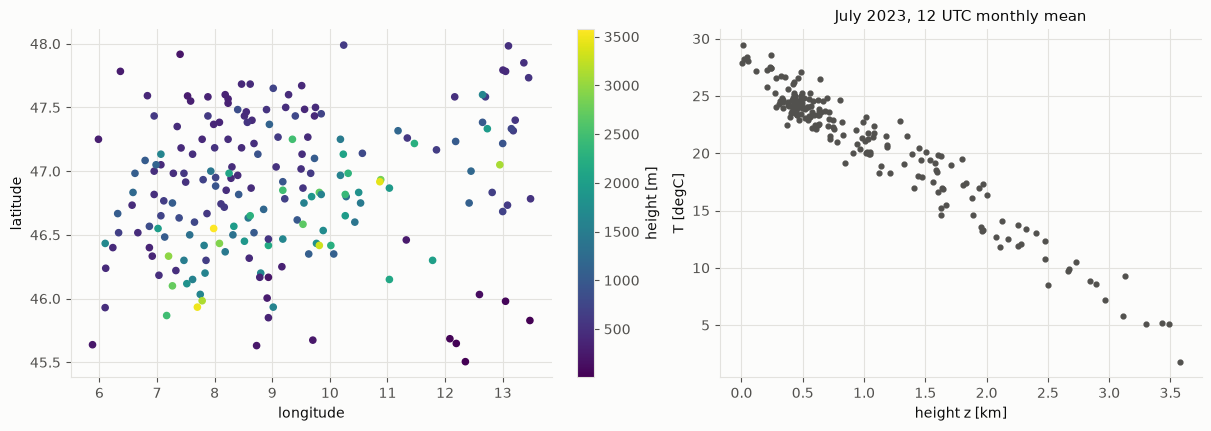

In [3]:
prob, meta = W.problem("july")
z, lon, lat = prob.x.T
fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))
sc = ax[0].scatter(lon, lat, c=z * 1000, cmap="viridis", s=20)
fig.colorbar(sc, ax=ax[0], label="height [m]")
ax[0].set_xlabel("longitude"); ax[0].set_ylabel("latitude")
ax[1].scatter(z, prob.y, s=12, color=P.INK_2)
ax[1].set_xlabel("height z [km]"); ax[1].set_ylabel("T [degC]")
ax[1].set_title("July 2023, 12 UTC monthly mean")
plt.show()

## 2 · Fit the law

The law is linear in its four constants, so the `physics` arm is ordinary
least squares, with an error bar from the covariance. That error bar assumes
the residuals are independent. They are not: stations in the same valley
share weather. Section 5 measures how much that matters.

In [4]:
full = fit_arm("physics", prob, np.arange(len(prob)), seed=11)
for k in ("T0", "a", "b", "Gamma"):
    print(f"{k:6s} = {full.params[k]:8.3f} +- {full.param_sigma[k]:.3f}")
print(f"ICAO standard atmosphere: Gamma = {W.GAMMA_STD}")
res = prob.y - full.predict(prob.x)
print(f"residual RMS {res.std():.2f} K")

T0     =   28.054 +- 0.131
a      =    0.170 +- 0.039
b      =   -1.388 +- 0.144
Gamma  =   -6.709 +- 0.097
ICAO standard atmosphere: Gamma = -6.5
residual RMS 1.04 K


## 3 · Extrapolate up the mountain

Train on the lowest 75% of stations by height, predict the highest 25%. The
black-box network has never seen a station above the training ceiling; the
law has a term that says what happens there.

In [5]:
itr, ite = W.elevation_split(prob)
print(f"train z <= {prob.x[itr, 0].max():.2f} km, test z up to {prob.x[ite, 0].max():.2f} km")
fits = {arm: fit_arm(arm, prob, itr, seed=11) for arm in ("physics", "pinn", "nn")}
for name, f in fits.items():
    e = f.predict(prob.x[ite]) - prob.y[ite]
    print(f"{name:8s} test RMSE {np.sqrt(np.mean(e**2)):5.2f} K   "
          f"mean dT/dz {W.effective_lapse_rate(f, prob.x):6.2f} K/km")

train z <= 1.51 km, test z up to 3.58 km


physics  test RMSE  1.98 K   mean dT/dz  -5.91 K/km
pinn     test RMSE  1.98 K   mean dT/dz  -5.91 K/km
nn       test RMSE  4.94 K   mean dT/dz  -5.64 K/km


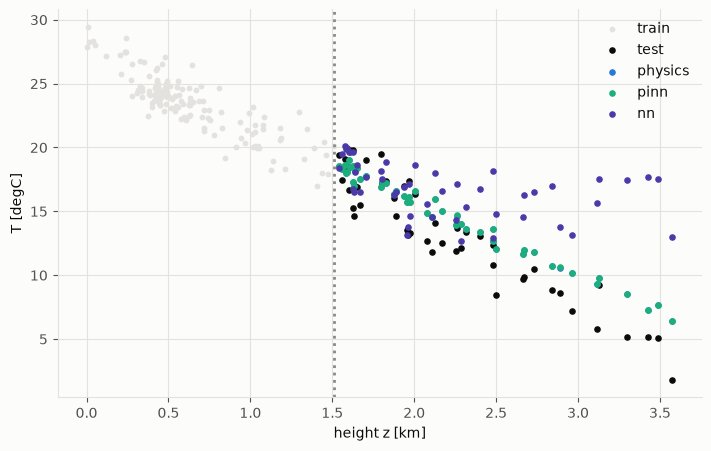

In [6]:
fig, ax = plt.subplots(figsize=(7, 4.4))
ax.scatter(prob.x[itr, 0], prob.y[itr], s=10, color=P.GRID, label="train")
ax.scatter(prob.x[ite, 0], prob.y[ite], s=14, color=P.INK, label="test")
for name, f in fits.items():
    ax.scatter(prob.x[ite, 0], f.predict(prob.x[ite]), s=14,
               color=P.ARM_COLOR[name], label=name)
ax.axvline(prob.x[itr, 0].max(), ls=":", color=P.INK_MUTED)
ax.set_xlabel("height z [km]"); ax.set_ylabel("T [degC]"); ax.legend()
plt.show()

The network's mean `dT/dz` is the derivative of what it learned, taken by
central differences at every station. It is a way to ask a black box what it
believes about height without reading its weights.

## 4 · Kriging

Meteorologists interpolate station data with Gaussian processes (kriging).
Two versions, both with hyperparameters chosen by maximum marginal
likelihood on the training stations:

* **ordinary kriging**: a constant mean plus a GP over east, north and
  height. A black box with a smoothness prior.
* **universal kriging**: the lapse-rate law as the mean, plus a GP on what
  the law leaves. This is the standard method for mapping temperature in
  mountains, and the fairest competitor the law-based arms have.

In [7]:
for kind in ("gp", "uk"):
    f = W.fit_kriging(prob, itr, kind)
    e = f.predict(prob.x[ite]) - prob.y[ite]
    hp = {k: round(v, 3) for k, v in f.extra["hyper"].items()}
    print(f"{kind}: test RMSE {np.sqrt(np.mean(e**2)):.2f} K  hyper {hp}  "
          f"converged {f.extra['converged']}")
    if kind == "uk":
        print(f"    Gamma = {f.params['Gamma']:.2f} +- {f.param_sigma['Gamma']:.2f} K/km")

gp: test RMSE 6.88 K  hyper {'l_h_km': 1000.0, 'l_z_km': 1.827, 's_f': 12.947, 's_n': 0.813}  converged False


uk: test RMSE 1.24 K  hyper {'l_h_km': 34.973, 'l_z_km': 0.544, 's_f': 0.965, 's_n': 0.472}  converged True
    Gamma = -6.57 +- 0.38 K/km


A length scale that ends at its bound has not converged, whatever the
optimiser reports, and is flagged. For ordinary kriging the horizontal
length scale tends to run to its upper bound: the likelihood wants a
smooth regional trend, which a constant-mean GP can only imitate with a
very long correlation length.

## 5 · The inversion case

In January the valleys fill with cold air. Over the lowest few hundred
metres temperature can rise with height, and a single linear lapse rate is
the wrong law. This is a known failure, and it is what the second case is
for.

January Gamma = -5.34 +- 0.09 K/km


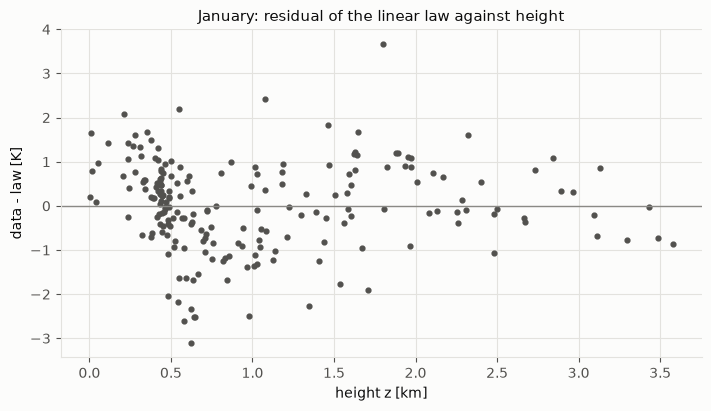

In [8]:
pj, _ = W.problem("january")
fj = fit_arm("physics", pj, np.arange(len(pj)), seed=11)
print(f"January Gamma = {fj.params['Gamma']:.2f} +- {fj.param_sigma['Gamma']:.2f} K/km")
rj = pj.y - fj.predict(pj.x)
fig, ax = plt.subplots(figsize=(7, 4))
ax.scatter(pj.x[:, 0], rj, s=12, color=P.INK_2)
ax.axhline(0, color=P.INK_MUTED, lw=1)
ax.set_xlabel("height z [km]"); ax.set_ylabel("data - law [K]")
ax.set_title("January: residual of the linear law against height")
plt.show()

## 6 · A simulated control

On real data a wrong $\Gamma$ could be the method's fault or the law's.
The simulation separates them: the same station positions, a field with a
known lapse rate, a spatially correlated residual drawn from a GP, and
optionally a cold pool. In the `law` case the least-squares $\Gamma$ should
be right on average; in the `inversion` case the best linear $\Gamma$ is
shallower than the free-air one, by an amount that is known.

In [9]:
xs = prob.x
for case in S.CASES:
    g = []
    for seed in range(1000, 1020):
        p, _ = S.problem(xs, case, seed)
        g.append(fit_arm("physics", p, np.arange(len(p)), seed).params["Gamma"])
    print(f"{case:9s} truth {S.TRUTH['Gamma']:.2f}, best linear "
          f"{S.best_linear_gamma(xs, case):.2f}, physics mean {np.mean(g):.2f} "
          f"sd {np.std(g):.2f}")

law       truth -5.00, best linear -5.00, physics mean -5.03 sd 0.22
inversion truth -5.00, best linear -3.00, physics mean -3.03 sd 0.22


## 7 · The full study

`physprior run fields` runs every arm (including PINN and symbolic
regression) on three reporting seeds, on the elevation split and on four
longitude blocks, plus the kriging baselines, the budget and noise sweeps,
the simulated control and an error-bar coverage study. The tables are in
`results/fields/weather/` and the write-up is `docs/fields/weather.md`.

In [10]:
from physprior.io import load_table
try:
    ex = load_table(W.track("july"), "extrapolation")
    kr = load_table(W.track("july"), "kriging")
    print(ex.groupby("arm")[["nrmse_out", "dTdz"]].median().round(3))
    print(kr[kr.sweep == "elevation"][["arm", "nrmse_out", "dTdz"]].round(3))
except FileNotFoundError:
    print("run `physprior run fields` first")

             nrmse_out   dTdz
arm                          
nn               0.914 -5.436
oracle           0.265 -6.500
physics          0.374 -5.909
pinn             0.375 -5.908
pinn_static      3.434  5.753
sr               0.356 -5.952
  arm  nrmse_out   dTdz
0  gp      1.298 -5.108
1  uk      0.234 -7.118


## Radio propagation: where is the transmitter?

A transmitter at an unknown position radiates at a fixed frequency. A handful
of receivers report the power they see, in dB, with noise. Two questions:
**what is the power everywhere** (the coverage map), and **where is the
transmitter**?

### The forward model

A time-harmonic field $u(x, y)\,e^{-i\omega t}$ obeys the Helmholtz equation

$$\nabla^2 u + k^2 n(x, y)^2 u = -f(x, y),$$

with $k = 2\pi/\lambda$, $n$ the complex refractive index (1 in air; about
$2.3 + 0.15i$ for concrete at 2.4 GHz, the imaginary part being loss), and
$f$ the source. `rf_sim.solve` discretises it with second-order finite
differences and closes the domain with a perfectly matched layer, a strip in
which the coordinates are stretched into the complex plane so that outgoing
waves decay without reflecting. The sparse system is solved directly.

Lengths are in wavelengths. The source is a small Gaussian rather than a
point, because the field of a 2-D point source is singular at the source and
would never converge with the grid.

17061 unknowns, solved in 0.3 s


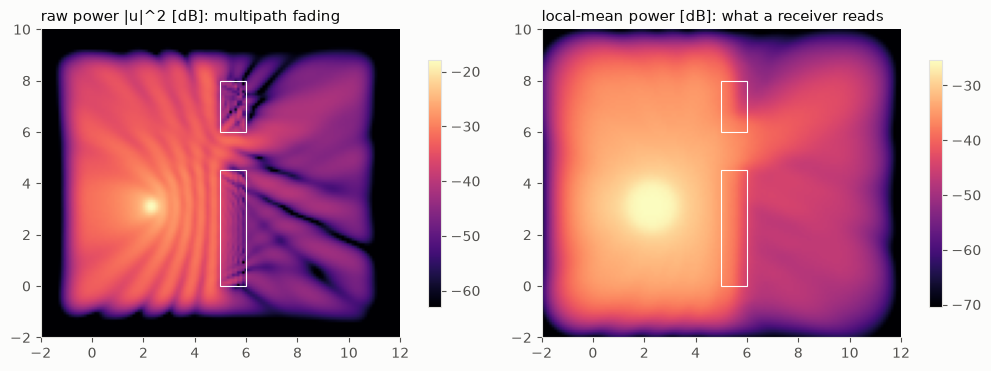

In [11]:
import numpy as np, matplotlib.pyplot as plt
from physprior.problems.fields import rf, rf_sim as S

# a small room: 10 x 8 wavelengths, one wall with a doorway
room = S.Scene(
    "demo",
    blocks=(S.Box(5.0, 6.0, 0.0, 4.5), S.Box(5.0, 6.0, 6.0, 8.0)),
    tx=(2.3, 3.1),
    width=10.0,
    height=8.0,
)
fld = S.solve(room, ppw=10)
print(f"{fld.meta['n_unknowns']} unknowns, solved in {fld.seconds:.1f} s")

fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))
for ax, arr, title in [
    (axes[0], fld.power_db(), "raw power |u|^2 [dB]: multipath fading"),
    (axes[1], fld.local_mean_db(), "local-mean power [dB]: what a receiver reads"),
]:
    im = ax.imshow(arr, origin="lower", cmap="magma",
                   extent=(fld.x[0], fld.x[-1], fld.y[0], fld.y[-1]),
                   vmin=arr.max() - 45, vmax=arr.max())
    ax.set_title(title, loc="left"); ax.grid(False)
    rf._walls(ax, room)
    fig.colorbar(im, ax=ax, shrink=0.8)
plt.show()

The raw power shows interference fringes half a wavelength apart: waves
reflected by the wall add to and cancel the direct wave. (The domain edges
reflect nothing: that is what the matched layer is for.) A received-signal
strength is an average over that fading, so the receivers here read the mean of
$|u|^2$ over a disk of one wavelength. The wall's shadow and the beam through
the doorway survive the averaging; the fringes do not.

### The law, and the inverse problem

The engineering model of path loss is the log-distance law

$$P(x, y) = P_0 - 10\, n \log_{10}\frac{d}{d_0}, \qquad
d = \lvert (x, y) - (x_t, y_t)\rvert .$$

In three dimensions free space has $n = 2$. In two dimensions a source
spreads over a circle rather than a sphere, $|u|^2 \sim 1/r$, so free space
has $n = 1$ here. Fitting the law to the readings is an inverse problem with
four unknowns: $P_0$, $n$, and the transmitter position $(x_t, y_t)$. The
position enters non-linearly, so the fit is started from several points.

In [12]:
rng = np.random.default_rng(0)
X, Y = np.meshgrid(fld.x, fld.y)
lm = fld.local_mean_db()
ok = ((X > 1) & (X < 9) & (Y > 1) & (Y < 7) & ~room.in_material(X, Y)
      & (np.hypot(X - room.tx[0], Y - room.tx[1]) > 1.5))
pick = rng.choice(np.flatnonzero(ok.ravel()), 60, replace=False)
xr = np.column_stack([X.ravel()[pick], Y.ravel()[pick]])
yr = lm.ravel()[pick] + rng.normal(0, rf.NOISE_DB, len(pick))

fit = rf.fit_law(room, xr, yr)
p = fit.params
print(f"true transmitter      ({room.tx[0]:.2f}, {room.tx[1]:.2f})")
print(f"recovered             ({p['xt']:.2f}, {p['yt']:.2f})   "
      f"error {np.hypot(p['xt'] - room.tx[0], p['yt'] - room.tx[1]):.2f} wavelengths")
print(f"path-loss exponent n  {p['n']:.2f} +/- {fit.param_sigma['n']:.2f}   (free space: 1)")

true transmitter      (2.30, 3.10)
recovered             (2.45, 3.65)   error 0.57 wavelengths
path-loss exponent n  2.46 +/- 0.25   (free space: 1)


With a wall in the way the fitted exponent tends to come out above 1: the law has no
term for a wall, so it steepens its distance dependence to absorb the loss.
This is the same mechanism as a constant absorbing a missing term elsewhere
in the project, and it is why the recovered exponent is not a property of the
building.

### The comparison

The full study (`rf.run()`) uses a 24 x 18 wavelength floor plan with three
rooms, and a free-space control with the same receivers. The arms:

| arm | what it knows |
|---|---|
| `oracle` | the free-space law at the true position, with the analytic $P_0$ and $n = 1$ |
| `physics` | the law, all four parameters fitted |
| `pinn` | the law plus a network correction (shape B), started from the physics fit |
| `pinn_free` | the same with the physics weight fixed at 1, no loss balancing |
| `nn` | a tuned MLP on $(x, y)$ |
| `gp` | ordinary kriging, a Gaussian process with a constant mean |
| `kriging` | the fitted law as the mean, plus a GP on its residuals |

The free-space control is the case where the law is complete; the floor plan
is the case where it misses the walls. Every arm is scored against the true
map, not only against held-out noisy readings.

In [13]:
from physprior.config import get_settings
try:
    t = rf.summary_tables()
except FileNotFoundError:
    t = None
    print("No results yet: run  rf.run()  (about an hour) or  rf.run(quick=True).")
if t is not None:
    print("Map RMSE against the truth [dB], median over reporting seeds")
    display(t["budget"].round(2))
    print("Transmitter error [wavelengths] and fitted exponent")
    display(t["tx"].round(2))

Map RMSE against the truth [dB], median over reporting seeds


n_train,scene,arm,n=16,n=32,n=64,n=128,n=256
0,free,gp,1.66,1.18,0.91,0.70,0.55
1,free,kriging,1.44,0.73,0.54,0.43,0.34
2,free,nn,3.62,4.51,3.74,2.07,1.24
3,free,oracle,0.07,0.07,0.07,0.07,0.07
4,free,physics,1.41,0.73,0.54,0.43,0.34
5,free,pinn,1.41,0.73,0.54,0.43,0.34
6,free,pinn_free,2.27,4.06,2.04,1.78,1.04
7,walls,gp,3.62,2.75,2.62,2.02,1.60
8,walls,kriging,5.60,4.90,2.58,1.94,1.52
9,walls,nn,7.90,4.89,3.02,2.13,1.36


Transmitter error [wavelengths] and fitted exponent


,scene,arm,n_train,tx_err_lambda,param_n,param_P0
0,free,physics,16,2.22,1.04,-28.75
1,free,physics,32,1.18,0.98,-29.09
2,free,physics,64,0.75,1.09,-28.54
3,free,physics,128,0.72,0.99,-29.21
4,free,physics,256,0.55,0.99,-29.06
5,free,pinn,16,2.22,1.04,-28.75
6,free,pinn,32,1.18,0.98,-29.09
7,free,pinn,64,0.75,1.09,-28.54
8,free,pinn,128,0.72,0.99,-29.21
9,free,pinn,256,0.55,0.99,-29.06


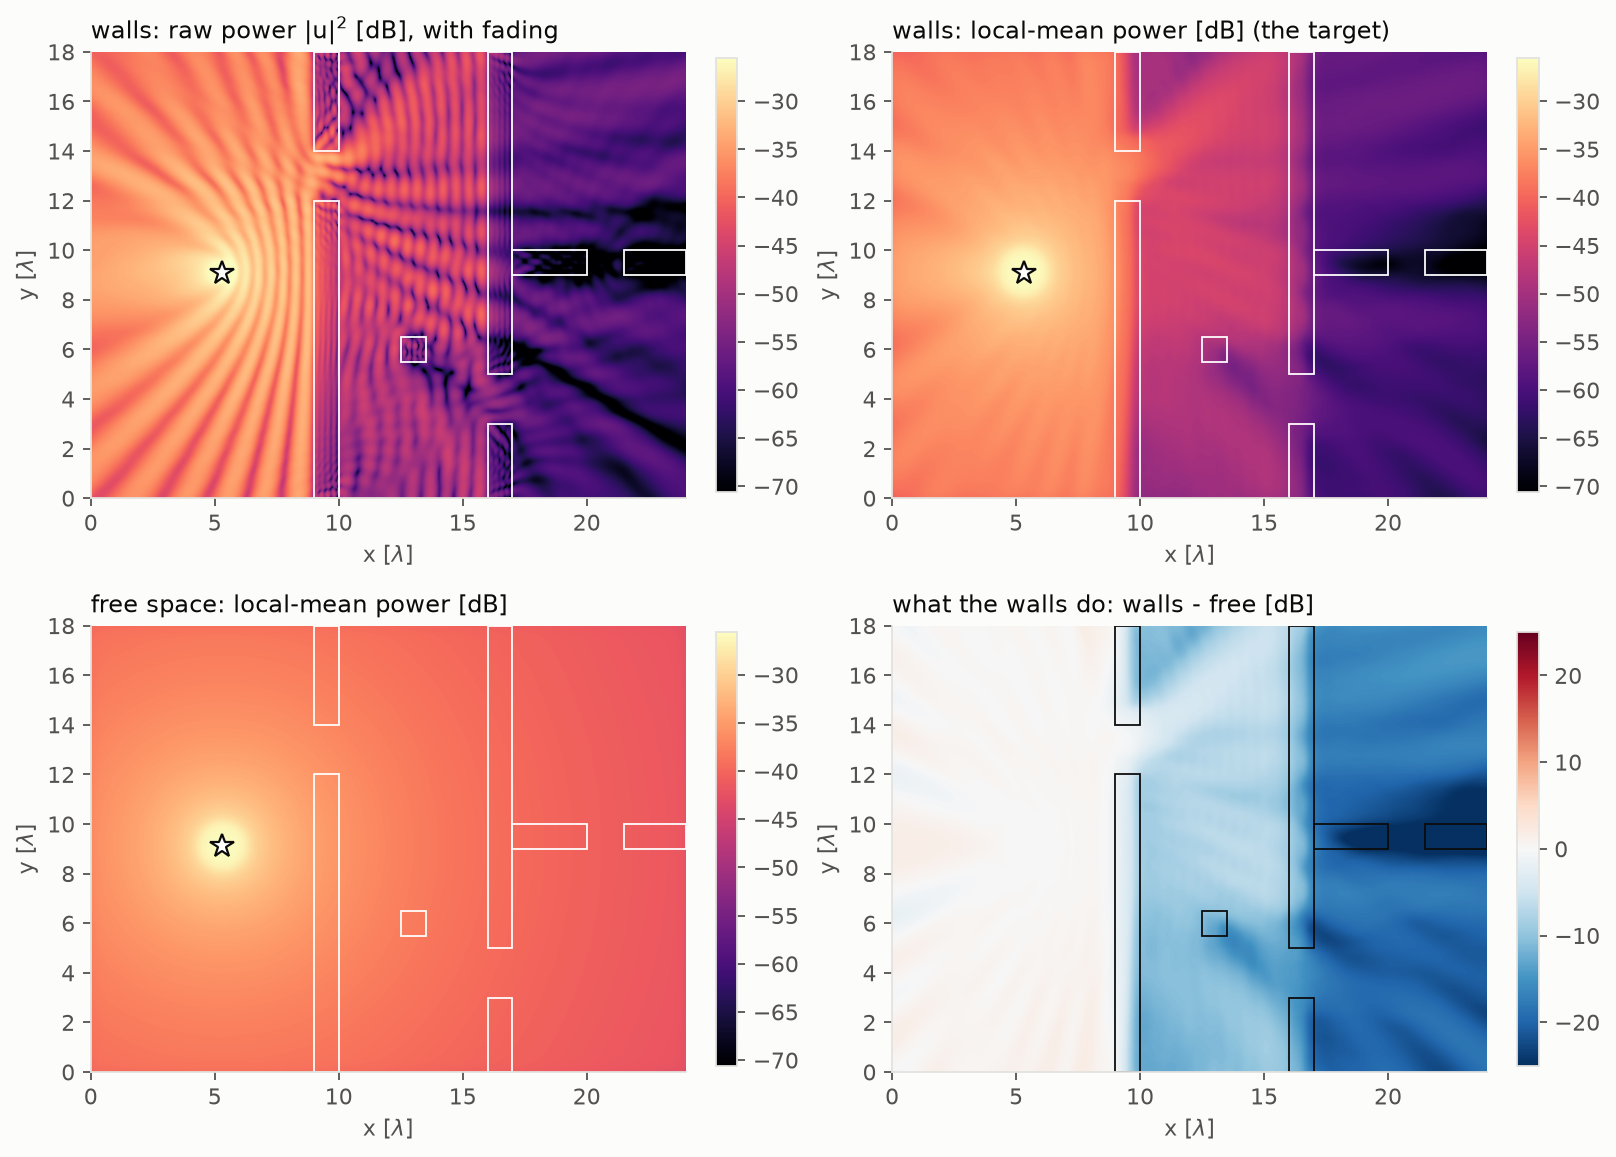

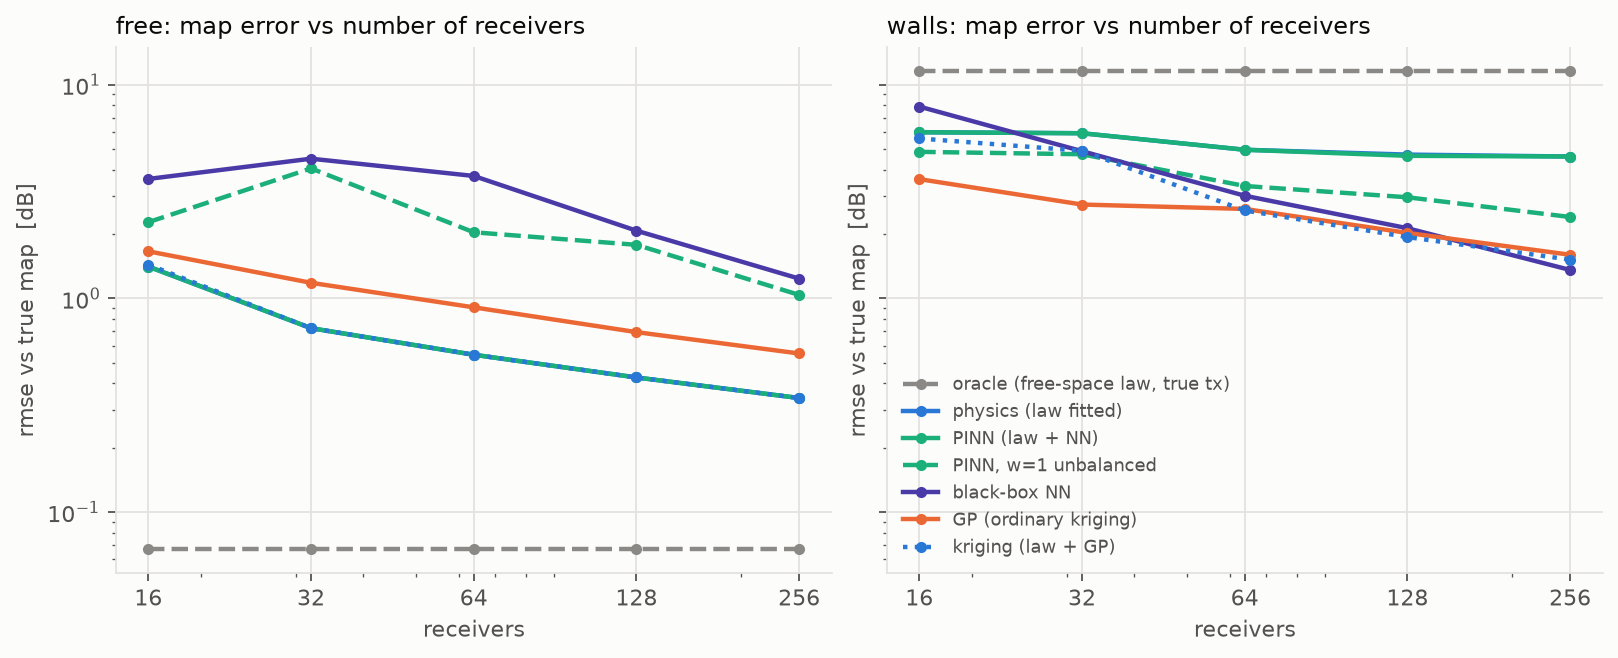

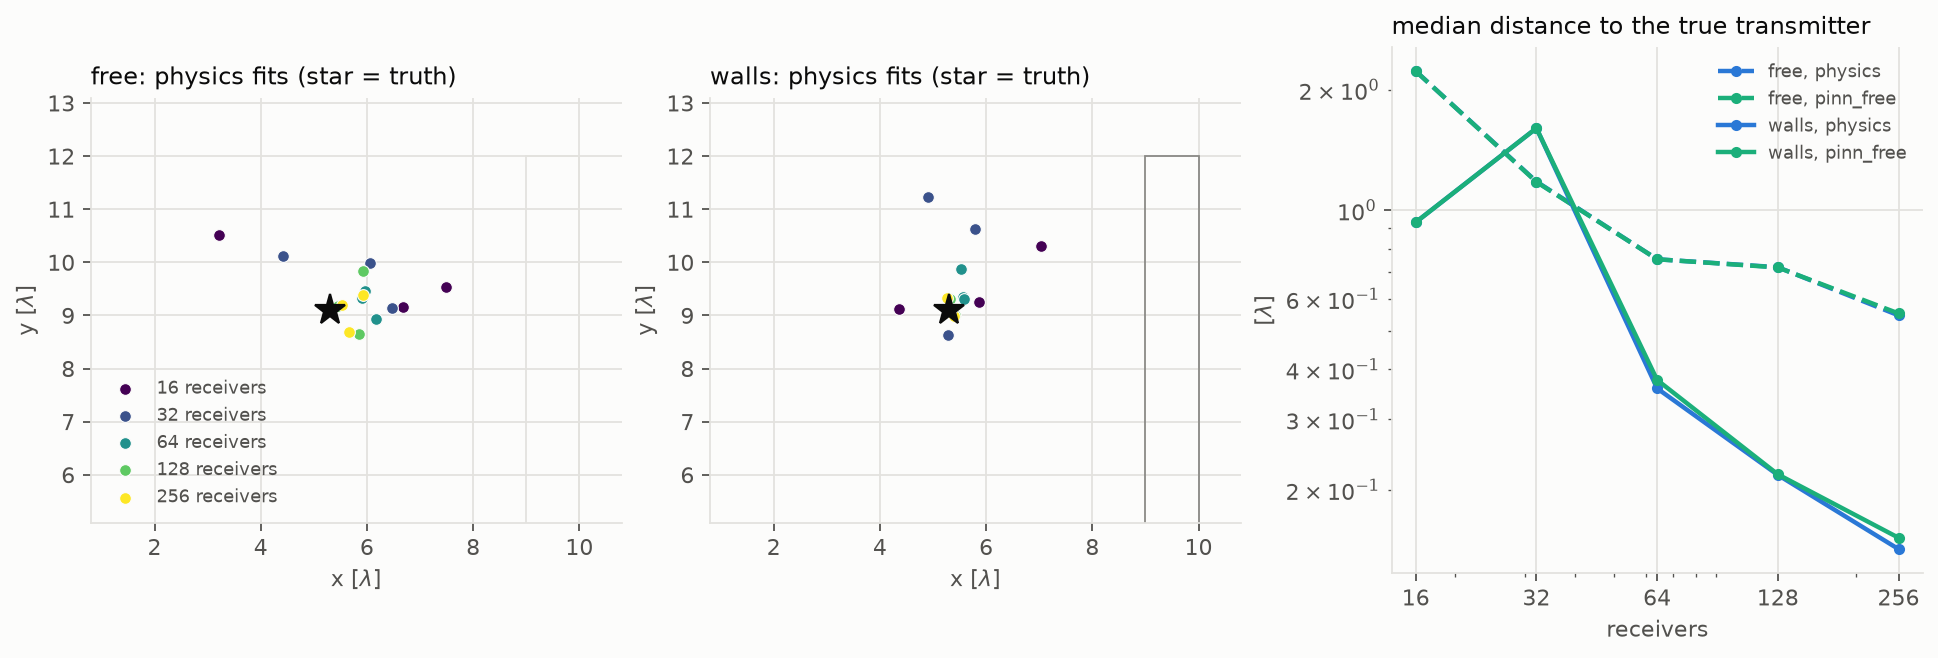

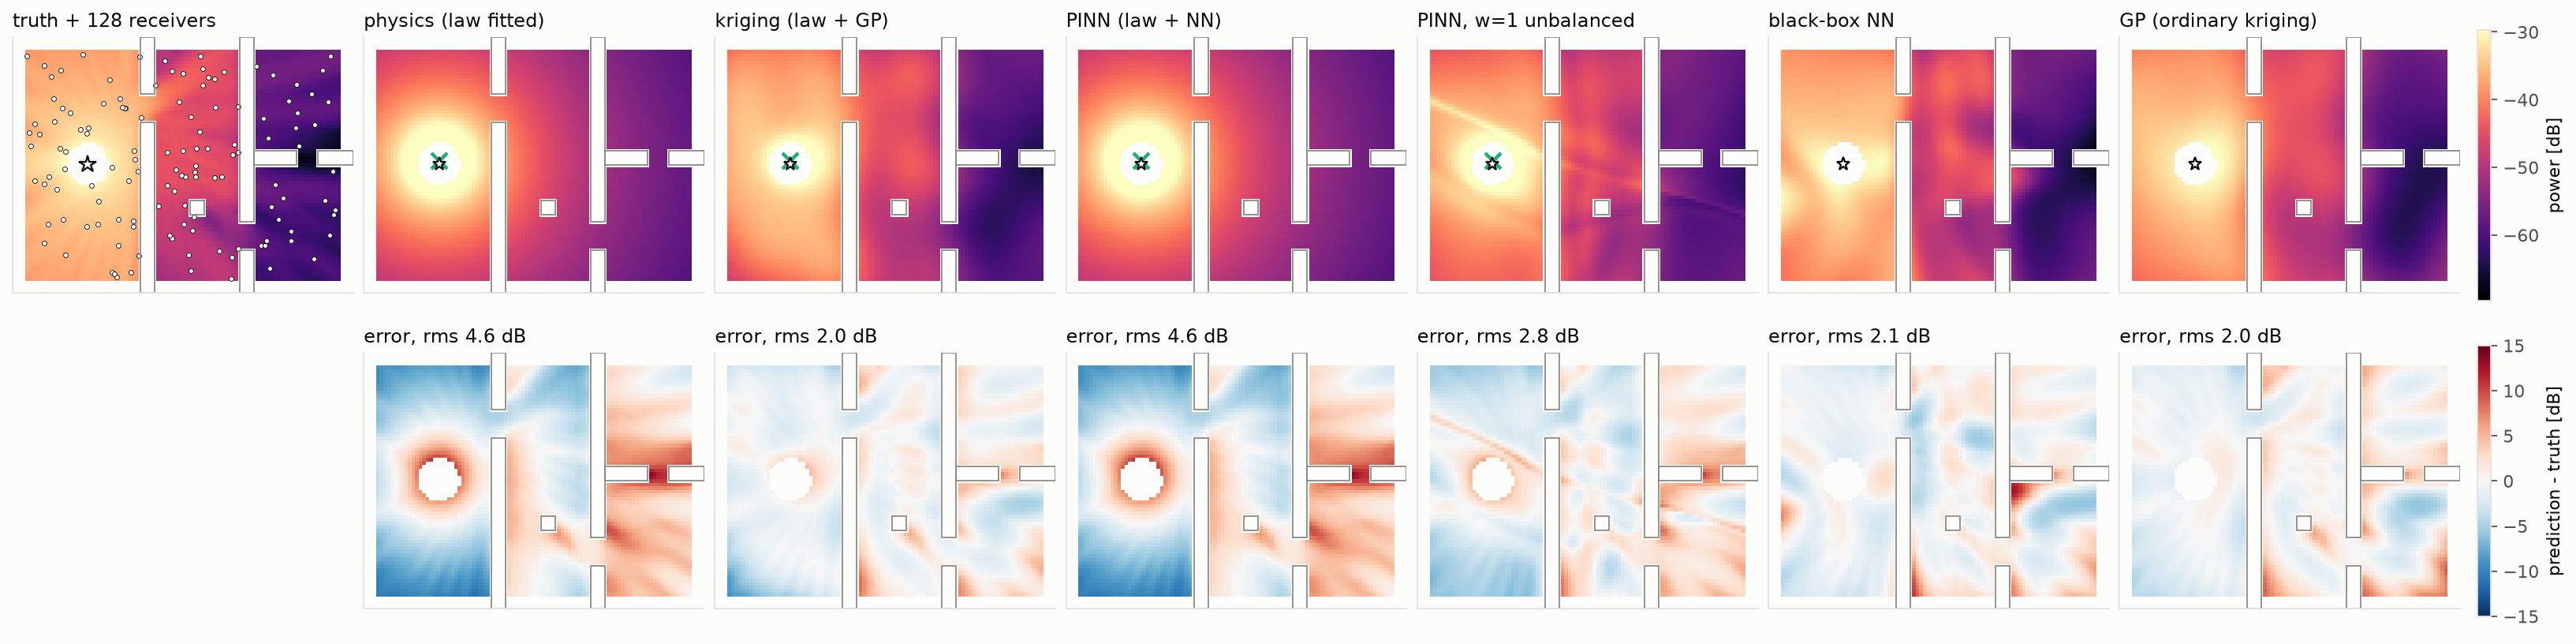

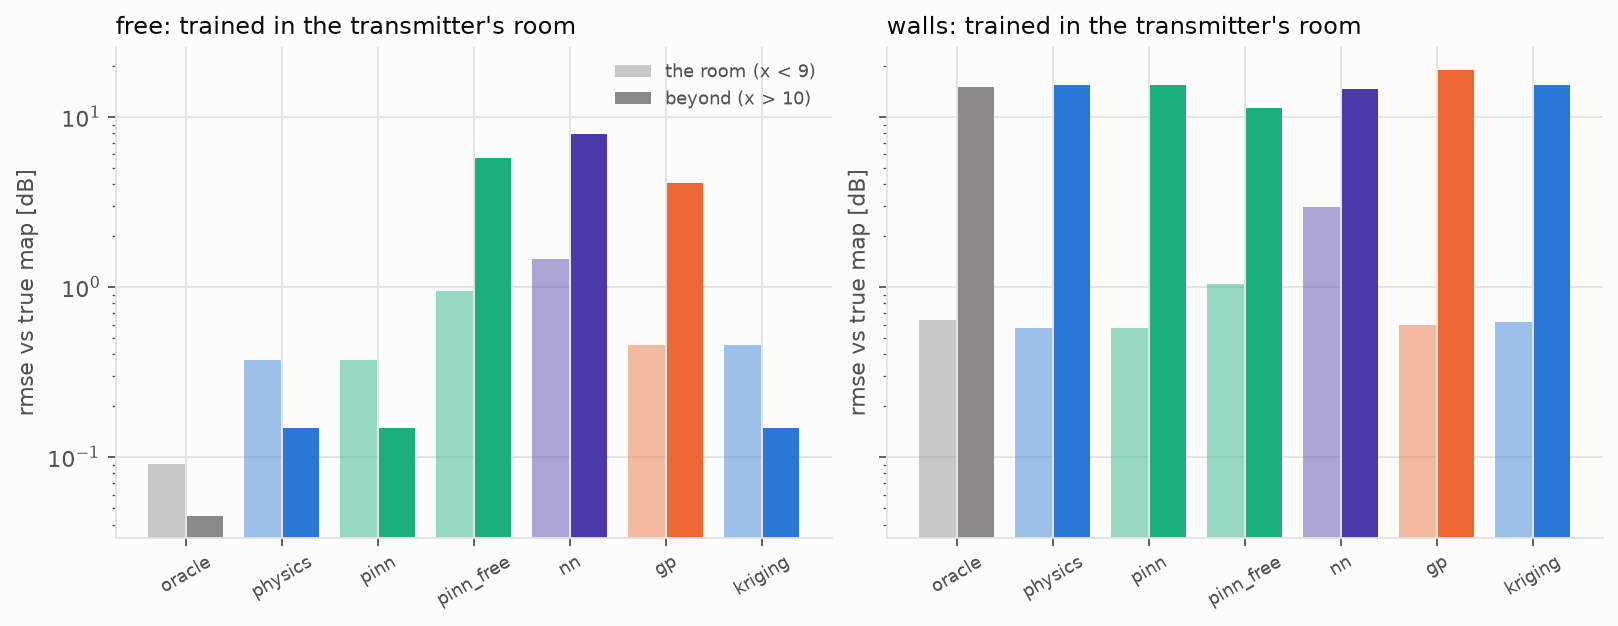

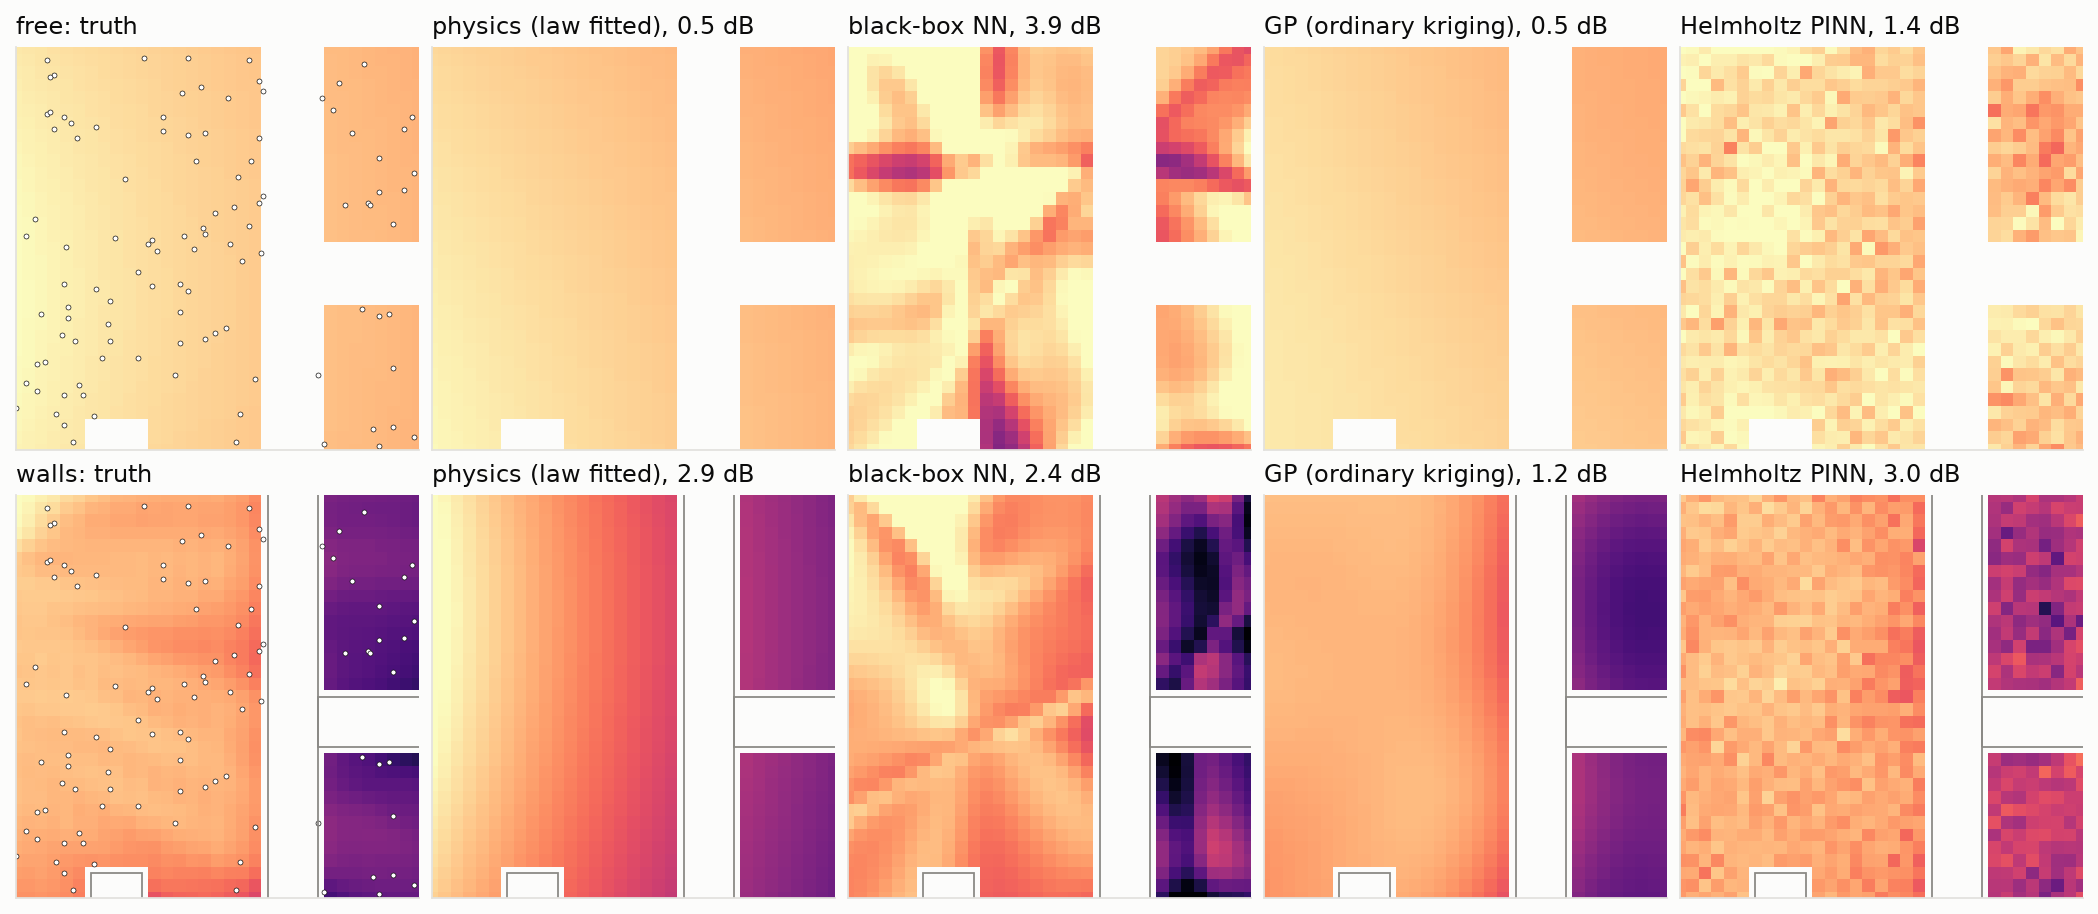

In [14]:
from IPython.display import Image, display
fig_dir = get_settings().figures("fields")
for name in ("rf_scene", "rf_budget", "rf_tx_recovery", "rf_reconstruction_walls",
             "rf_extrapolation", "rf_helmholtz_window"):
    path = fig_dir / f"{name}.png"
    if path.exists():
        display(Image(filename=str(path)))

### Reading the results

Three things to look for in the tables above.

1. **Free space.** The law is exact there, so `physics` should sit near the
   oracle and recover the transmitter; a correction (`pinn`, `kriging`) has
   nothing to find and can only add variance.
2. **The floor plan.** The law cannot make a step at a wall. Whatever an arm
   gains over `physics` here is the wall losses it learned from the
   receivers, and the gain should be largest where the receivers are dense.
3. **Extrapolation.** Trained only in the transmitter's room, no arm has seen
   a wall's effect. The law extrapolates its free-space shape through the
   walls; the data-driven arms extrapolate whatever their prior is.

A Helmholtz-residual PINN (shape A) is compared separately on a window of the
scene. It is given the refractive-index map, which the other arms are not,
and still faces a problem the readings do not pin down: power has no phase,
and a window with no boundary condition admits many solutions of the
equation.